## 0. Setup

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import gc
from pathlib import Path
from sklearn.metrics import log_loss
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.feature_extraction import FeatureHasher
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.5f}'.format)

SEED     = 42
np.random.seed(SEED)
DATA_DIR = Path('/kaggle/input/competitions/the-ad-ecosystem-and-ctr-prediction')
TARGET   = 'clicked'
ID_COL   = 'impression_id'

print('Libraries loaded.')

Libraries loaded.


## 1. Load + EDA

In [42]:
train = pd.read_csv(DATA_DIR / 'train.csv', parse_dates=['timestamp'])
test  = pd.read_csv(DATA_DIR / 'test.csv',  parse_dates=['timestamp'])

train[TARGET]      = train[TARGET].astype(int)
train['is_app']    = train['is_app'].astype(int)
test['is_app']     = test['is_app'].astype(int)

P_BAR = train[TARGET].mean()

def nce(y_true, y_pred):
    """Normalized Cross-Entropy — lower is better, < 1.0 beats naive baseline."""
    ll_model    = log_loss(y_true, y_pred)
    ll_baseline = log_loss(y_true, np.full(len(y_true), P_BAR))
    return ll_model / ll_baseline

print(f'Train {train.shape} | Test {test.shape}')
print(f'Background CTR p̄ = {P_BAR:.5f}')
print(f'Train: {train.timestamp.min()} → {train.timestamp.max()}')
print(f'Test:  {test.timestamp.min()} → {test.timestamp.max()}')

Train (374590, 28) | Test (125410, 27)
Background CTR p̄ = 0.30689
Train: 2024-01-01 00:00:00 → 2024-01-21 23:00:00
Test:  2024-01-22 00:00:00 → 2024-01-28 23:00:00


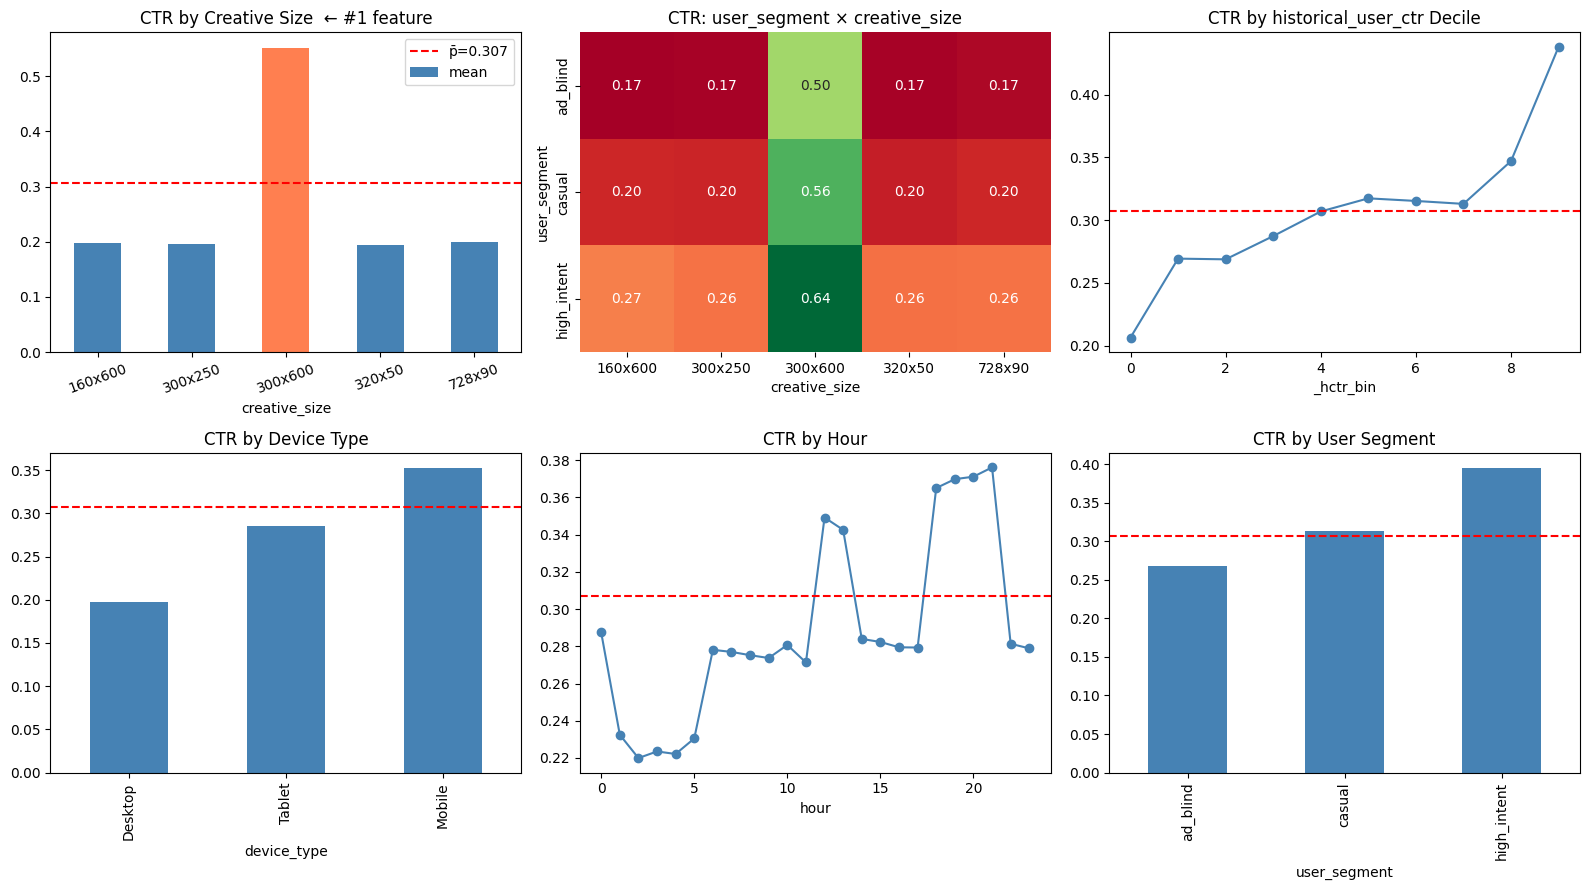

In [43]:
# The dominant signal: creative_size=300x600 has 55% CTR vs ~20% for everything else
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# creative_size : "ขนาดของโฆษณา" มีผลต่อการคลิกแค่ไหน
cs_ctr = train.groupby('creative_size')[TARGET].agg(['mean','count'])
cs_ctr['mean'].plot(kind='bar', ax=axes[0,0], color=['coral' if v=='300x600' else 'steelblue'
                                                       for v in cs_ctr.index])
axes[0,0].axhline(P_BAR, color='red', linestyle='--', label=f'p̄={P_BAR:.3f}')
axes[0,0].set_title('CTR by Creative Size  ← #1 feature')
axes[0,0].legend()
axes[0,0].tick_params(axis='x', rotation=20)

# user_segment × creative_size heatmap :  heatmap "user_segment" กับ "creative_size" เพื่อดูว่าผู้ใช้กลุ่มไหน เมื่อเจอโฆษณาขนาดไหนแล้วจะคลิกเยอะที่สุด
pivot = train.groupby(['user_segment','creative_size'])[TARGET].mean().unstack()
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[0,1], cbar=False)
axes[0,1].set_title('CTR: user_segment × creative_size')

# historical_user_ctr deciles : เพื่อพิสูจน์ว่าคนที่ประวัติในอดีตชอบคลิกโฆษณาบ่อยๆ จะมีแนวโน้มคลิกโฆษณาในครั้งนี้สูงตามไปด้วยหรือไม่
train['_hctr_bin'] = pd.qcut(train['historical_user_ctr'], q=10, duplicates='drop', labels=False)
train.groupby('_hctr_bin')[TARGET].mean().plot(marker='o', ax=axes[0,2], color='steelblue')
axes[0,2].axhline(P_BAR, color='red', linestyle='--')
axes[0,2].set_title('CTR by historical_user_ctr Decile')

# device_type : เพื่อดูว่าคนใช้อุปกรณ์แบบไหนตอบสนองกับโฆษณาดีที่สุด
train.groupby('device_type')[TARGET].mean().sort_values().plot(
    kind='bar', ax=axes[1,0], color='steelblue')
axes[1,0].axhline(P_BAR, color='red', linestyle='--')
axes[1,0].set_title('CTR by Device Type')

# hour : เพื่อหา Prime time ว่าคนมักจะตื่นตัวและกดคลิกโฆษณาในเวลาไหนของวันมากที่สุด
train.groupby('hour')[TARGET].mean().plot(marker='o', ax=axes[1,1], color='steelblue')
axes[1,1].axhline(P_BAR, color='red', linestyle='--')
axes[1,1].set_title('CTR by Hour')

# user_segment : เพื่อดูภาพรวมว่าเป้าหมายกลุ่มไหนที่สนใจโฆษณาของเรามากที่สุด (โดยไม่ได้แยกตามขนาดโฆษณาเหมือน graph ที่ 2)
train.groupby('user_segment')[TARGET].mean().sort_values().plot(
    kind='bar', ax=axes[1,2], color='steelblue')
axes[1,2].axhline(P_BAR, color='red', linestyle='--')
axes[1,2].set_title('CTR by User Segment')

plt.tight_layout()
plt.show()

train.drop(columns=['_hctr_bin'], inplace=True)

## 2. Feature Engineering 

In [44]:
t0 = time.time()

test[TARGET] = -1
combined = pd.concat([train, test], ignore_index=True, sort=False)
N_TRAIN  = len(train)
print(f'Combined: {combined.shape}')

Combined: (500000, 28)


In [45]:
# --- 2.1 Semantic Null Mapping ---
# app_id/app_domain null when is_app=0; site_id/site_domain null when is_app=1
ALL_CAT = [
    'device_type','device_model','device_conn_type',
    'banner_pos','site_id','site_domain','site_category',
    'app_id','app_domain','ad_id','ad_campaign_id',
    'publisher_id','creative_size','user_segment',
    'C1','C15','C16','C21'
]
for col in ALL_CAT:
    combined[col] = combined[col].fillna('MISSING').astype(str)# fillna with MISSING แทน
print('Semantic nulls mapped.')

Semantic nulls mapped.


In [46]:
# --- 2.2 High-signal explicit binary features ---
# 300x600 is so dominant (55% CTR vs 20%) it deserves an explicit flag
# ใช้ signal ที่ได้จากการ EDA มาทำ feature engineering
combined['is_300x600']  = (combined['creative_size'] == '300x600').astype(np.int8)
combined['is_highintent'] = (combined['user_segment'] == 'high_intent').astype(np.int8)
combined['is_adblind']    = (combined['user_segment'] == 'ad_blind').astype(np.int8)

# historical_user_ctr decile bin (10 buckets → captures non-linearity)
combined['hist_ctr_decile'] = pd.qcut(
    combined['historical_user_ctr'], q=10,
    labels=False, duplicates='drop'
).fillna(0).astype(str)   # string so it goes through TE as categorical

print('Explicit binary features + hist_ctr_decile done.')

Explicit binary features + hist_ctr_decile done.


In [47]:
# --- 2.3 Cyclical Temporal Encoding ---
# แปลงตัวเลขชั่วโมงให้อยู่ในรูปของ Sine/Cosine เพื่อช่วยให้ model เข้าใจว่าเวลา 23:00 น. กับ 00:00 น. นั้น "อยู่ติดกัน" ไม่ใช่ตัวเลขที่ห่างกันตามคณิตศาสตร์ปกติ
combined['hour_sin']      = np.sin(2 * np.pi * combined['hour'] / 24)
combined['hour_cos']      = np.cos(2 * np.pi * combined['hour'] / 24)

#แปลงชื่อวันจันทร์-อาทิตย์ เป็นตัวเลข 0-6 แล้วจับเข้าสมการวงกลม เพื่อให้ model รู้ว่าวันอาทิตย์เชื่อมต่อกับวันจันทร์
dow_map = {'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,
           'Friday':4,'Saturday':5,'Sunday':6}
combined['dow_num']       = combined['day_of_week'].map(dow_map).fillna(0).astype(int)
combined['dow_sin']       = np.sin(2 * np.pi * combined['dow_num'] / 7)
combined['dow_cos']       = np.cos(2 * np.pi * combined['dow_num'] / 7)

combined['is_weekend']    = (combined['dow_num'] >= 5).astype(np.int8) # พฤติกรรมการเล่นเน็ตและคลิกโฆษณาวันหยุดมักจะต่างจากวันธรรมดา
combined['is_prime_time'] = combined['hour'].between(19, 23).astype(np.int8) # ช่วงหลังเลิกงานที่คนมักจะเล่นมือถือเยอะ
combined['is_commute']    = combined['hour'].isin([7, 8, 17, 18]).astype(np.int8) # ช่วงเวลา เดินทางไป-กลับที่ทำงาน เป็นช่วงที่คนมักจะหยิบมือถือขึ้นมา doom scrolling ระหว่างเดินทาง
combined['hour_bin']      = pd.cut(combined['hour'],
                                   bins=[-1,5,11,17,23],
                                   labels=[0,1,2,3]).astype(str) # แบ่งช่วง ดึก, เช้า, บ่าย, ค่ำ
print('Cyclical temporal encoding done.')

Cyclical temporal encoding done.


In [48]:
# --- 2.4 Cross / Interaction Features ---
# Priority: creative_size × context (most predictive interactions)
combined['creative_x_userseg']   = combined['creative_size'] + '_' + combined['user_segment']
combined['creative_x_device']    = combined['creative_size'] + '_' + combined['device_type']
combined['creative_x_isapp']     = combined['creative_size'] + '_' + combined['is_app'].astype(str)
combined['creative_x_banner']    = combined['creative_size'] + '_' + combined['banner_pos']
combined['creative_x_hctr']      = combined['creative_size'] + '_' + combined['hist_ctr_decile']

# Other useful interactions
combined['banner_x_site_cat']    = combined['banner_pos']      + '_' + combined['site_category']
combined['device_x_conn']        = combined['device_type']     + '_' + combined['device_conn_type']
combined['campaign_x_creative']  = combined['ad_campaign_id']  + '_' + combined['creative_size']
combined['app_x_banner']         = combined['is_app'].astype(str) + '_' + combined['banner_pos']
combined['site_cat_x_hourbin']   = combined['site_category']   + '_' + combined['hour_bin']
combined['pub_x_site_cat']       = combined['publisher_id']    + '_' + combined['site_category']
combined['pub_x_creative']       = combined['publisher_id']    + '_' + combined['creative_size']
combined['userseg_x_device']     = combined['user_segment']    + '_' + combined['device_type']
combined['userseg_x_banner']     = combined['user_segment']    + '_' + combined['banner_pos']

CROSS_COLS = [
    'creative_x_userseg','creative_x_device','creative_x_isapp',
    'creative_x_banner','creative_x_hctr',
    'banner_x_site_cat','device_x_conn','campaign_x_creative',
    'app_x_banner','site_cat_x_hourbin','pub_x_site_cat',
    'pub_x_creative','userseg_x_device','userseg_x_banner'
]
ALL_CAT_FINAL = ALL_CAT + CROSS_COLS + ['hour_bin','hist_ctr_decile']
print(f'Cross features: {len(CROSS_COLS)} created.')

Cross features: 14 created.


In [49]:
# --- 2.5 Frequency Encoding ---
# การนับสถิติความถี่ว่า ข้อมูลแต่ละอย่าง เช่น ผู้ใช้คนนี้, เว็บไซต์นี้, โฆษณาตัวนี้ โผล่มาให้เห็นบ่อยแค่ไหน
FREQ_COLS = ['user_id','site_id','app_id','ad_id','ad_campaign_id',
             'device_model','user_segment','publisher_id']

train_only = combined.iloc[:N_TRAIN]
for col in FREQ_COLS:
    freq_map = train_only[col].value_counts()
    combined[f'{col}_freq']     = combined[col].map(freq_map).fillna(0).astype(np.float32)
    combined[f'{col}_freq_log'] = np.log1p(combined[f'{col}_freq']).astype(np.float32)

# Ad-fatigue signal: (user_id, ad_id) co-occurrence in training
# Reflects how many times user already saw this specific ad
pair_counts = (train_only.groupby(['user_id','ad_id'])
               .size()
               .reset_index(name='user_ad_freq'))
combined = combined.merge(pair_counts, on=['user_id','ad_id'], how='left')
combined['user_ad_freq'] = combined['user_ad_freq'].fillna(0).astype(np.float32)

# (user_id, ad_campaign_id) exposure count
pair_camp = (train_only.groupby(['user_id','ad_campaign_id'])
             .size()
             .reset_index(name='user_camp_freq'))
combined = combined.merge(pair_camp, on=['user_id','ad_campaign_id'], how='left')
combined['user_camp_freq'] = combined['user_camp_freq'].fillna(0).astype(np.float32)

print('Frequency encoding done.')

Frequency encoding done.


In [50]:
# --- 2.6 Smoothed Target Encoding (Temporal K-Fold, No Leakage) ---
# Forward-only folds: fold k is encoded only from folds 0..k-1

ALPHA   = 20
N_FOLDS = 5

# Base columns
TE_BASE = [
    'site_id','app_id','ad_id','ad_campaign_id','publisher_id',
    'site_category','app_domain','site_domain',
    'device_type','banner_pos','user_segment','creative_size',
    'device_model','C1','C15','C16','C21'
]
# Critical interaction columns — derived from EDA: creative_size is #1 signal
TE_INTERACTIONS = [
    'creative_x_userseg',    # user segment × creative → big split
    'creative_x_device',     # mobile vs desktop response to 300x600
    'creative_x_isapp',      # app vs web × creative
    'creative_x_banner',     # banner position × creative
    'creative_x_hctr',       # user quality × creative
    'banner_x_site_cat',
    'campaign_x_creative',
    'pub_x_creative',        # publisher × creative
    'userseg_x_device',
    'userseg_x_banner',
    'hist_ctr_decile',        # non-linear bucketing of user quality
]
TE_COLS = TE_BASE + TE_INTERACTIONS

tr_df = combined.iloc[:N_TRAIN].copy().reset_index(drop=True)
te_df = combined.iloc[N_TRAIN:].copy().reset_index(drop=True)
y_all = tr_df[TARGET].values

# Temporal fold assignment (sorted by timestamp, forward-only)
time_order  = tr_df['timestamp'].argsort().values
fold_assign = np.zeros(N_TRAIN, dtype=int)
fold_size   = N_TRAIN // N_FOLDS
for f in range(N_FOLDS):
    fold_assign[time_order[f*fold_size : (f+1)*fold_size]] = f
fold_assign[time_order[N_FOLDS*fold_size:]] = N_FOLDS - 1

print(f'Fold sizes: {np.bincount(fold_assign)}')
print(f'TE columns: {len(TE_COLS)}')

Fold sizes: [74918 74918 74918 74918 74918]
TE columns: 28


In [51]:
def smooth_encode(vals, targets, alpha, global_mean):
    s = {}
    for v, y in zip(vals, targets):
        if v not in s:
            s[v] = [0.0, 0]
        s[v][0] += y
        s[v][1] += 1
    return {v: (st[0] + alpha * global_mean) / (st[1] + alpha)
            for v, st in s.items()}

for col in TE_COLS:
    vals_tr = tr_df[col].astype(str).values
    vals_te = te_df[col].astype(str).values
    oof     = np.full(N_TRAIN, P_BAR, dtype=np.float32)

    for fold in range(1, N_FOLDS):
        past = fold_assign < fold
        curr = fold_assign == fold
        enc  = smooth_encode(vals_tr[past], y_all[past], ALPHA, P_BAR)
        for i in np.where(curr)[0]:
            oof[i] = enc.get(vals_tr[i], P_BAR)

    enc_all = smooth_encode(vals_tr, y_all, ALPHA, P_BAR)
    tr_df[f'{col}_te'] = oof
    te_df[f'{col}_te'] = np.array([enc_all.get(v, P_BAR) for v in vals_te], dtype=np.float32)

print(f'Target encoding done — {len(TE_COLS)} columns.')

Target encoding done — 28 columns.


In [52]:
# --- 2.7 Numerical Transforms ---
for df in [tr_df, te_df]:
    df['user_depth_log']  = np.log1p(df['user_depth']).astype(np.float32)
    df['hist_ctr_log']    = np.log1p(df['historical_user_ctr']).astype(np.float32)
    df['hist_ctr_delta']  = (df['historical_user_ctr'] - P_BAR).astype(np.float32)
    # Interaction: user quality × creative dominance (manually specified because 300x600 effect)
    df['hctr_x_300x600']  = (df['historical_user_ctr'] * df['is_300x600']).astype(np.float32)
    df['hctr_x_highintent'] = (df['historical_user_ctr'] * df['is_highintent']).astype(np.float32)
    df['user_ad_freq_log']  = np.log1p(df['user_ad_freq']).astype(np.float32)
    df['user_camp_freq_log'] = np.log1p(df['user_camp_freq']).astype(np.float32)
    df['depth_bin']          = pd.qcut(df['user_depth'], q=5,
                                       labels=False, duplicates='drop').fillna(0).astype(np.int8)

print('Numerical transforms done.')
print(f'Feature engineering total: {(time.time()-t0)/60:.1f} min')

Numerical transforms done.
Feature engineering total: 0.5 min


In [53]:
# --- 2.8 Label Encode Categoricals for LightGBM ---
for col in ALL_CAT_FINAL:
    if col not in tr_df.columns:
        continue
    le  = LabelEncoder()
    all_vals = pd.concat([tr_df[col].astype(str), te_df[col].astype(str)])
    le.fit(all_vals)
    cls_set    = set(le.classes_)
    fallback   = le.classes_[0]
    tr_df[col] = le.transform(tr_df[col].astype(str))
    te_df[col] = le.transform(
        te_df[col].astype(str).map(lambda x: x if x in cls_set else fallback)
    )

print('Label encoding done.')

Label encoding done.


## 3. Validation Split + Feature Matrix

In [54]:
# Time-based split: last 15% = validation (mirrors temporal gap to test week)
val_cutoff = tr_df['timestamp'].quantile(0.85)
val_mask   = tr_df['timestamp'] >= val_cutoff

EXCLUDE    = {TARGET, ID_COL, 'timestamp', 'user_id', 'day_of_week', 'hour', 'dow_num'}
FEAT_COLS  = [c for c in tr_df.columns if c not in EXCLUDE]
CAT_FEATS  = [c for c in ALL_CAT_FINAL if c in FEAT_COLS]

X      = tr_df[FEAT_COLS]
y      = tr_df[TARGET].values
X_test = te_df[FEAT_COLS]

X_tr,  X_val  = X[~val_mask].reset_index(drop=True), X[val_mask].reset_index(drop=True)
y_tr,  y_val  = y[~val_mask], y[val_mask]

print(f'Train: {X_tr.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Total features : {len(FEAT_COLS)}')
print(f'Cat features   : {len(CAT_FEATS)}')
print(f'Val CTR  : {y_val.mean():.5f}')
print(f'Train CTR: {y_tr.mean():.5f}')

Train: (317619, 102)  Val: (56971, 102)  Test: (125410, 102)
Total features : 102
Cat features   : 34
Val CTR  : 0.30675
Train CTR: 0.30691


## 4. LightGBM 

In [55]:
import lightgbm as lgb

lgb_params = {
    'objective':         'binary',
    'metric':            'binary_logloss',
    'boosting_type':     'gbdt',
   
    'num_leaves':        511,
    'max_depth':         -1,
    'min_child_samples': 20,
    'learning_rate':     0.02,
    'feature_fraction':  0.7,
    'bagging_fraction':  0.8,
    'bagging_freq':      1,
    'reg_alpha':         0.05,
    'reg_lambda':        1.0,
    'min_split_gain':    0.001,
    'path_smooth':       0.1,    # reduces overfitting on sparse interaction features
    'scale_pos_weight':  (1 - P_BAR) / P_BAR,
    'random_state':      SEED,
    'n_jobs':            -1,
    'verbose':           -1,
}

dtrain = lgb.Dataset(X_tr,  label=y_tr,  categorical_feature=CAT_FEATS)
dval   = lgb.Dataset(X_val, label=y_val, categorical_feature=CAT_FEATS, reference=dtrain)

t_lgb = time.time()
model_lgb = lgb.train(
    lgb_params,
    dtrain,
    num_boost_round=4000,
    valid_sets=[dval],
    valid_names=['val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=200, verbose=True),
        lgb.log_evaluation(period=300),
    ],
)
print(f'\nLightGBM time: {(time.time()-t_lgb)/60:.1f} min | Best iter: {model_lgb.best_iteration}')

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[57]	val's binary_logloss: 0.549935

LightGBM time: 1.0 min | Best iter: 57


In [56]:
val_pred_lgb  = model_lgb.predict(X_val)
test_pred_lgb = model_lgb.predict(X_test)

print(f'LightGBM  Val NCE     : {nce(y_val, val_pred_lgb):.5f}')
print(f'LightGBM  Val LogLoss : {log_loss(y_val, val_pred_lgb):.5f}')
print(f'Pred mean: {val_pred_lgb.mean():.5f}  (p̄={P_BAR:.5f})')

LightGBM  Val NCE     : 0.89206
LightGBM  Val LogLoss : 0.54994
Pred mean: 0.40647  (p̄=0.30689)


<Figure size 1000x800 with 0 Axes>

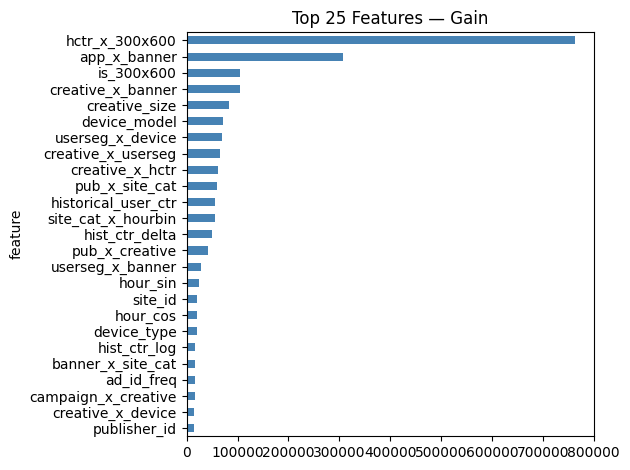

            feature         gain
     hctr_x_300x600 762580.67652
       app_x_banner 307198.68921
         is_300x600 105363.65186
  creative_x_banner 105317.99219
      creative_size  83468.04233
       device_model  71553.03743
   userseg_x_device  70066.33550
 creative_x_userseg  65029.35550
    creative_x_hctr  61700.99703
     pub_x_site_cat  58961.59309
historical_user_ctr  56563.10483
 site_cat_x_hourbin  56249.61814
     hist_ctr_delta  49129.81695
     pub_x_creative  42227.71331
   userseg_x_banner  28167.93956
           hour_sin  25098.32135
            site_id  20120.71409
           hour_cos  19690.33231
        device_type  19583.59154
       hist_ctr_log  17351.58305


In [57]:
# Feature importance
fi = pd.DataFrame({
    'feature': FEAT_COLS,
    'gain':    model_lgb.feature_importance('gain'),
}).sort_values('gain', ascending=False)

plt.figure(figsize=(10, 8))
fi.head(25).plot(x='feature', y='gain', kind='barh', color='steelblue', legend=False)
plt.title('Top 25 Features — Gain')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print(fi.head(20).to_string(index=False))

## 5. CatBoost 

In [58]:
try:
    from catboost import CatBoostClassifier, Pool
    HAS_CATBOOST = True
    print('CatBoost available.')
except ImportError:
    HAS_CATBOOST = False
    print('CatBoost not installed. Run: pip install catboost')
    print('Will proceed with LightGBM + FTRL ensemble only.')

CatBoost available.


In [60]:
if HAS_CATBOOST:
    X_tr_cb   = X_tr.copy()
    X_val_cb  = X_val.copy()
    X_test_cb = X_test.copy()
    for col in CAT_FEATS:
        if col in X_tr_cb.columns:
            X_tr_cb[col]   = X_tr_cb[col].astype(np.int32)
            X_val_cb[col]  = X_val_cb[col].astype(np.int32)
            X_test_cb[col] = X_test_cb[col].astype(np.int32)

    pool_tr  = Pool(X_tr_cb,  label=y_tr,  cat_features=CAT_FEATS, feature_names=FEAT_COLS)
    pool_val = Pool(X_val_cb, label=y_val, cat_features=CAT_FEATS, feature_names=FEAT_COLS)

    cat_params = {
        'iterations':            2000,
        'learning_rate':         0.05,
        'depth':                 8,
        'loss_function':         'Logloss',
        'eval_metric':           'Logloss',
        'random_seed':           SEED,
        'early_stopping_rounds': 100,
        'verbose':               200,
        'l2_leaf_reg':           3.0,
        'border_count':          128,
        'class_weights':         {0: 1.0, 1: (1-P_BAR)/P_BAR},
    }

    t_cat     = time.time()
    model_cat = CatBoostClassifier(**cat_params)
    model_cat.fit(pool_tr, eval_set=pool_val, use_best_model=True)
    print(f'CatBoost time: {(time.time()-t_cat)/60:.1f} min')

    pool_val_pred  = Pool(X_val_cb,  cat_features=CAT_FEATS, feature_names=FEAT_COLS)
    pool_test_pred = Pool(X_test_cb, cat_features=CAT_FEATS, feature_names=FEAT_COLS)

    val_pred_cat  = model_cat.predict_proba(pool_val_pred)[:, 1]
    test_pred_cat = model_cat.predict_proba(pool_test_pred)[:, 1]
    print(f'CatBoost Val NCE: {nce(y_val, val_pred_cat):.5f}')
else:
    val_pred_cat  = None
    test_pred_cat = None

0:	learn: 0.6814505	test: 0.6814291	best: 0.6814291 (0)	total: 1.96s	remaining: 1h 5m 27s
200:	learn: 0.5660848	test: 0.5683048	best: 0.5683048 (200)	total: 5m 10s	remaining: 46m 17s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.568192003
bestIteration = 293

Shrink model to first 294 iterations.
CatBoost time: 10.3 min
CatBoost Val NCE: 0.92652


## 6. FTRL 

In [61]:
# Re-read original string categories for hash-trick encoding
combined_raw = pd.concat([train, test], ignore_index=True, sort=False)
for col in ALL_CAT:
    combined_raw[col] = combined_raw[col].fillna('MISSING').astype(str)

tr_raw = combined_raw.iloc[:N_TRAIN].copy().reset_index(drop=True)
te_raw = combined_raw.iloc[N_TRAIN:].copy().reset_index(drop=True)

HASH_COLS = ALL_CAT + CROSS_COLS[:8]   # top 8 crosses for hash space
for col in CROSS_COLS[:8]:
    if col not in tr_raw.columns:
        tr_raw[col] = tr_df[col].astype(str).values[:N_TRAIN]
        te_raw[col] = te_df[col].astype(str).values

def make_hash_dicts(df, cols):
    arrs  = [df[c].astype(str).values for c in cols if c in df.columns]
    valid = [c for c in cols if c in df.columns]
    for row in zip(*arrs):
        yield {f'{c}={v}': 1 for c, v in zip(valid, row)}

hasher    = FeatureHasher(n_features=2**20, input_type='dict')
tr_raw_tr = tr_raw[tr_df['timestamp'] < val_cutoff]
tr_raw_vl = tr_raw[tr_df['timestamp'] >= val_cutoff]

X_tr_sp   = hasher.fit_transform(make_hash_dicts(tr_raw_tr, HASH_COLS))
X_val_sp  = hasher.transform(make_hash_dicts(tr_raw_vl, HASH_COLS))
X_test_sp = hasher.transform(make_hash_dicts(te_raw, HASH_COLS))

t_ftrl   = time.time()
ftrl     = SGDClassifier(loss='log_loss', penalty='elasticnet',
                         l1_ratio=0.15, alpha=1e-5, max_iter=8,
                         class_weight='balanced', random_state=SEED, n_jobs=-1)
ftrl.fit(X_tr_sp, y_tr)

val_pred_ftrl  = ftrl.predict_proba(X_val_sp)[:, 1]
test_pred_ftrl = ftrl.predict_proba(X_test_sp)[:, 1]

print(f'FTRL time: {(time.time()-t_ftrl)/60:.1f} min')
print(f'FTRL  Val NCE: {nce(y_val, val_pred_ftrl):.5f}')

FTRL time: 0.0 min
FTRL  Val NCE: 0.99346


## 7. Calibration

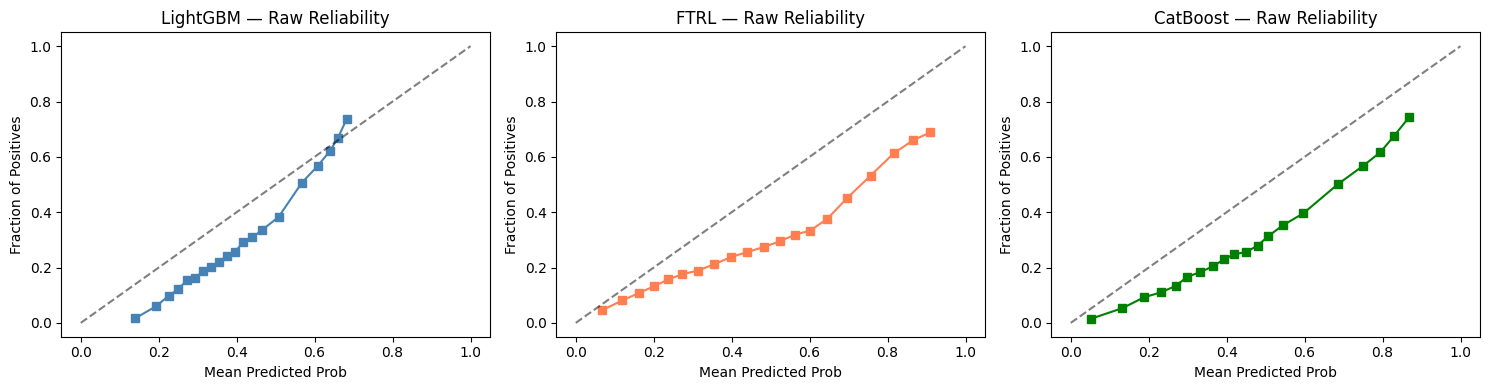

In [62]:
# Reliability diagrams before calibration
models_to_show = [('LightGBM', val_pred_lgb, 'steelblue'),
                  ('FTRL',     val_pred_ftrl, 'coral')]
if val_pred_cat is not None:
    models_to_show.append(('CatBoost', val_pred_cat, 'green'))

fig, axes = plt.subplots(1, len(models_to_show), figsize=(5*len(models_to_show), 4))
if len(models_to_show) == 1:
    axes = [axes]

for ax, (name, preds, color) in zip(axes, models_to_show):
    fp, mp = calibration_curve(y_val, preds, n_bins=20, strategy='quantile')
    ax.plot(mp, fp, 's-', color=color)
    ax.plot([0,1],[0,1],'k--', alpha=0.5)
    ax.set_title(f'{name} — Raw Reliability')
    ax.set_xlabel('Mean Predicted Prob')
    ax.set_ylabel('Fraction of Positives')

plt.tight_layout()
plt.show()

In [63]:
# ทำ Probability Calibration ด้วย
# 1.Platt Scaling ใช้ Logistic Regression เข้ามาช่วยเกลี่ยตัวเลขความน่าจะเป็นให้สมูทขึ้น ป้องกันการ overfit เหมาะกับ dataset ที่มีจำนวนไม่เยอะ
# 2.Isotonic Regression มีเงื่อนไขแค่ว่า "ถ้า AI มั่นใจมากขึ้น โอกาสคลิกจริงก็ต้องห้ามน้อยลง" เหมาะกับ dataset ที่มีขนาดใหญ่เช่นใน mini hack นี้
def platt_scale(val_p, val_y, test_p):
    """Logistic regression on raw predictions (Platt scaling)."""
    lr = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000)
    lr.fit(val_p.reshape(-1,1), val_y)
    return (lr.predict_proba(val_p.reshape(-1,1))[:,1],
            lr.predict_proba(test_p.reshape(-1,1))[:,1])

def isotonic_scale(val_p, val_y, test_p):
    """Isotonic regression calibration — more flexible than Platt."""
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(val_p, val_y)
    return iso.predict(val_p), iso.predict(test_p)

# Pick best calibration per model by NCE on val
def best_calibrate(val_p, val_y, test_p, name):
    platt_val, platt_test = platt_scale(val_p, val_y, test_p)
    iso_val,   iso_test   = isotonic_scale(val_p, val_y, test_p)
    nce_raw    = nce(val_y, val_p)
    nce_platt  = nce(val_y, platt_val)
    nce_iso    = nce(val_y, iso_val)
    print(f'{name:12s}  raw={nce_raw:.5f}  platt={nce_platt:.5f}  isotonic={nce_iso:.5f}', end='')
    if nce_platt <= nce_iso:
        print('  → using Platt')
        return platt_val, platt_test
    else:
        print('  → using Isotonic')
        return iso_val, iso_test

val_lgb_cal,  test_lgb_cal  = best_calibrate(val_pred_lgb,  y_val, test_pred_lgb,  'LightGBM')
val_ftrl_cal, test_ftrl_cal = best_calibrate(val_pred_ftrl, y_val, test_pred_ftrl, 'FTRL')

if val_pred_cat is not None:
    val_cat_cal, test_cat_cal = best_calibrate(val_pred_cat, y_val, test_pred_cat, 'CatBoost')
else:
    val_cat_cal, test_cat_cal = None, None

LightGBM      raw=0.89206  platt=0.83627  isotonic=0.83092  → using Isotonic
FTRL          raw=0.99346  platt=0.86571  isotonic=0.86119  → using Isotonic
CatBoost      raw=0.92652  platt=0.82934  isotonic=0.82473  → using Isotonic


## 8. Ensemble 

In [64]:
# Collect calibrated models
models = [
    ('LightGBM', val_lgb_cal,  test_lgb_cal),
    ('FTRL',     val_ftrl_cal, test_ftrl_cal),
]
if val_cat_cal is not None:
    models.append(('CatBoost', val_cat_cal, test_cat_cal))

nce_scores = {name: nce(y_val, vp) for name, vp, _ in models}
print('Calibrated NCE per model:')
for name, score in nce_scores.items():
    print(f'  {name:12s}: {score:.5f}')

# Inverse-NCE weighting
weights  = {name: 1.0 / score for name, score in nce_scores.items()}
w_total  = sum(weights.values())
weights  = {name: w / w_total for name, w in weights.items()}
print('\nEnsemble weights:')
for name, w in weights.items():
    print(f'  {name:12s}: {w:.3f}')

val_blend  = sum(weights[n] * vp for n, vp, _ in models)
test_blend = sum(weights[n] * tp for n, _, tp in models)

Calibrated NCE per model:
  LightGBM    : 0.83092
  FTRL        : 0.86119
  CatBoost    : 0.82473

Ensemble weights:
  LightGBM    : 0.336
  FTRL        : 0.325
  CatBoost    : 0.339


In [65]:
print(f'Blend Val NCE (before re-cal): {nce(y_val, val_blend):.5f}')

# Re-calibrate the blend itself
val_final, test_final = best_calibrate(val_blend, y_val, test_blend, 'Blend')

# NCE summary table
rows = [
    {'Model': 'Naive baseline p̄',   'Val NCE': 1.00000},
    {'Model': 'LightGBM raw',        'Val NCE': nce(y_val, val_pred_lgb)},
    {'Model': 'LightGBM calibrated', 'Val NCE': nce(y_val, val_lgb_cal)},
    {'Model': 'FTRL calibrated',     'Val NCE': nce(y_val, val_ftrl_cal)},
]
if val_cat_cal is not None:
    rows.append({'Model': 'CatBoost calibrated', 'Val NCE': nce(y_val, val_cat_cal)})
rows.append({'Model': 'FINAL BLEND',         'Val NCE': nce(y_val, val_final)})

results = pd.DataFrame(rows)
results['vs_baseline'] = (1 - results['Val NCE']).map(lambda x: f'+{x:.3%}' if x>0 else f'{x:.3%}')
print()
print(results.to_string(index=False))

Blend Val NCE (before re-cal): 0.83103
Blend         raw=0.83103  platt=0.83688  isotonic=0.82850  → using Isotonic

              Model  Val NCE vs_baseline
  Naive baseline p̄  1.00000      0.000%
       LightGBM raw  0.89206    +10.794%
LightGBM calibrated  0.83092    +16.908%
    FTRL calibrated  0.86119    +13.881%
CatBoost calibrated  0.82473    +17.527%
        FINAL BLEND  0.82850    +17.150%


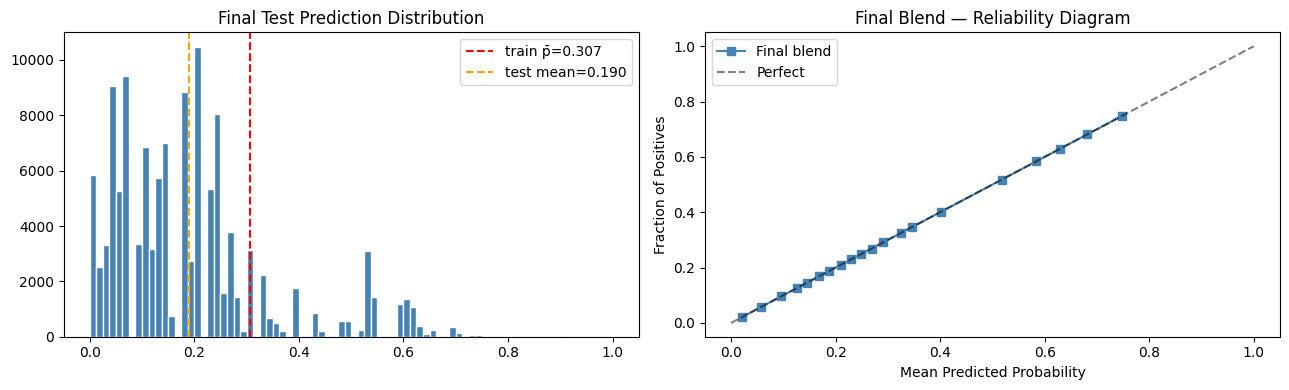

In [66]:
# Final distribution + reliability
test_final = np.clip(test_final, 1e-7, 1 - 1e-7)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(test_final, bins=80, color='steelblue', edgecolor='white')
axes[0].axvline(P_BAR,           color='red',    linestyle='--', label=f'train p̄={P_BAR:.3f}')
axes[0].axvline(test_final.mean(), color='orange', linestyle='--',
                label=f'test mean={test_final.mean():.3f}')
axes[0].set_title('Final Test Prediction Distribution')
axes[0].legend()

fp, mp = calibration_curve(y_val, val_final, n_bins=20, strategy='quantile')
axes[1].plot(mp, fp, 's-', color='steelblue', label='Final blend')
axes[1].plot([0,1],[0,1],'k--', alpha=0.5, label='Perfect')
axes[1].set_title('Final Blend — Reliability Diagram')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Submission

In [67]:
assert not np.isnan(test_final).any(), 'NaN in predictions!'
assert not np.isinf(test_final).any(), 'Inf in predictions!'
assert (test_final > 0).all() and (test_final < 1).all(), 'Out-of-range predictions!'

print('All checks passed.')
print(f'mean  = {test_final.mean():.5f}  (train p̄ = {P_BAR:.5f})')
print(f'std   = {test_final.std():.5f}')
print(f'min   = {test_final.min():.6f}')
print(f'max   = {test_final.max():.6f}')

submission = pd.DataFrame({'impression_id': test[ID_COL].values, 'clicked': test_final})
submission.to_csv('submission.csv', index=False)
print(f'\nSaved submission.csv — {len(submission):,} rows')
submission.head()

All checks passed.
mean  = 0.19023  (train p̄ = 0.30689)
std   = 0.15360
min   = 0.000000
max   = 1.000000

Saved submission.csv — 125,410 rows


,impression_id,clicked
0,imp_00000008,0.17642
1,imp_00000009,0.00000
2,imp_00000013,0.05409
3,imp_00000017,0.23012
4,imp_00000023,0.30192
